# Melting-Ice — a quantitative teardown 🔬
### The exact constant-leverage identity · drag-vs-drift decomposition · break-even vol

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Always decays to zero?: Busted](https://img.shields.io/badge/Always_decays_to_zero%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its identity.* We implement the Cheng-Madhavan daily rebalancing identity, validate it against the real funds, split the gap-to-naive-3x into the Avellaneda-Zhang variance-drag and the compounding terms, and locate the break-even volatility where decay finally wins.

> ⚠️ **Not investment advice.** TQQQ/QQQ & UPRO/SPY daily, total-return adjusted (`quantlab.data`, Yahoo); 3x sleeve charged ~5%/yr all-in (expense + financing). Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (melting_ice/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from melting_ice import data, strategy

AS_OF = "2026-06-12"
under, letf, meta = data.load_pair("TQQQ", end=AS_OF)   # QQQ -> TQQQ (3x)
uc, lc = under["close"], letf["close"]
nav  = strategy.simulate_letf(uc, k=3.0)                # simulated 3x from QQQ
real = lc / lc.iloc[0]                                  # real TQQQ, base 1
naive = strategy.naive_k_curve(uc, k=3.0)               # the "3x the period return" line
under_n = uc / uc.iloc[0]                               # QQQ, base 1
print(f"TQQQ pair: {meta['start']} -> {meta['end']}  ({meta['n']:,} rows)")
print(f"fingerprints: QQQ={data.fingerprint(under)}  TQQQ={data.fingerprint(letf)}")
print(f"real TQQQ final x{real.iloc[-1]:.1f}   sim final x{nav.iloc[-1]:.1f}   naive-3x x{naive.iloc[-1]:.1f}")


TQQQ pair: 2010-02-11 -> 2026-06-12  (4,109 rows)
fingerprints: QQQ=2bc863129115  TQQQ=5ad580bd5ea3
real TQQQ final x376.2   sim final x368.9   naive-3x x55.1


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `REAL` | The decay mechanic is exact: the daily identity reproduces real TQQQ/UPRO at corr **0.9989/0.9983**, RMS err <20 bps, final NAV within ~2%. Drag = `(k(k-1)/2)·σ²` is real maths. |
| **Tradability** | `MIRAGE` | 'Hold 3x forever' earned **+24/+18 pts/yr** but at a **lower Sharpe** than the underlying (-0.08/-0.09) and a -81.7%/-76.8% drawdown — regime-conditional leverage, not alpha. |
| **Always decays to zero?** | `BUSTED` | Realised 3x x369/x121 vs naive-3x x55/x31 — ended far ABOVE, not below. |

> 💡 **In plain words:** the maths the warning rests on is correct; the conclusion it draws ('therefore doomed') is not — in a trend, compounding flips the sign.

## 1 · The claim, steelmanned

The constant-leverage fund compounds `L_T = ∏(1 + k·r_t − fee)`, which is **not** the naive `1 + k·(∏(1+r_t) − 1)`. Using daily log-returns `x_t` with mean `g`, variance `s²`:

$$\;\mathbb{E}[\log(1+k r)]\;\approx\; \underbrace{k\,g}_{\text{drift}}\;-\;\underbrace{\tfrac{k(k-1)}{2}\,s^2}_{\text{variance drag}}.$$

- **H₁ (mechanism real):** the identity reproduces the real funds.
- **H₂ (decay real but conditional):** drag dominates only above a break-even variance.
- **H₃ (the sold claim):** 3x *always* decays toward zero over long horizons.

H₁ and H₂ hold; H₃ is false — exactly the split we find.

## 2 · So what?

If H₃ held, leveraged ETFs would be a maths trap with no honest long holder. The truth — they're a *path-dependent leveraged-beta bet* — changes the risk you're actually taking from 'guaranteed bleed' to 'catastrophic drawdown in the wrong regime.'

## 3 · How we'd know — the protocol

Reproduce the real fund from the identity · decompose drift vs drag with the log-return expansion · solve for break-even variance · contrast regimes (trend vs chop) · alpha-vs-beta read via Sharpe-vs-underlying.

## 4 · The teardown

**Reproduction** — the identity vs the real funds:

In [2]:
rows = []
for name in ['TQQQ','UPRO']:
    u, l, m = data.load_pair(name, end=AS_OF)
    rep = strategy.reproduction_error(u['close'], l['close'], k=3.0)
    rows.append([name, m['underlying'], rep['corr'], rep['rms_te_bps'], rep['final_ratio']])
pd.DataFrame(rows, columns=['fund','underlying','daily corr','RMS err (bps)','final ratio sim/real']).set_index('fund').round(3)

,underlying,daily corr,RMS err (bps),final ratio sim/real
fund,,,,
TQQQ,QQQ,0.999,18.633,0.981
UPRO,SPY,0.998,19.053,0.984


> 💡 **In plain words:** the rebuild *is* the fund. corr 0.999 means the daily decay mechanic is captured exactly — nothing hidden.

**Realised 3x vs naive-3x**, and the **drag-vs-drift** decomposition with break-even vol:

In [3]:
rows = []
for name in ['TQQQ','UPRO']:
    u, l, m = data.load_pair(name, end=AS_OF); c = u['close']
    rvn = strategy.realized_vs_naive(c, k=3.0); d = strategy.drag_decomposition(c, k=3.0)
    rows.append([name, rvn['realized_final'], rvn['naive_final'], d['drift_ann']*100, d['drag_ann']*100,
                 d['net_leading_ann']*100, d['realized_vol_ann']*100, d['breakeven_vol_ann']*100, d['drag_dominates']])
cols = ['fund','realised 3x','naive 3x','drift %/yr','drag %/yr','net %/yr','realised vol %','break-even vol %','drag dom?']
pd.DataFrame(rows, columns=cols).set_index('fund').round(1)

,realised 3x,naive 3x,drift %/yr,drag %/yr,net %/yr,realised vol %,break-even vol %,drag dom?
fund,,,,,,,,
TQQQ,368.900,55.100,54.200,12.800,41.400,20.600,42.500,False
UPRO,121.200,30.600,42.300,8.800,33.500,17.100,37.500,False


For k=3 the break-even is `s²* = g`, i.e. ~42% / 38% annualised vol. Both underlyings ran at ~21% / 17% — **well below** break-even — so the +drift term beat the −drag term and the 3x compounded ahead.

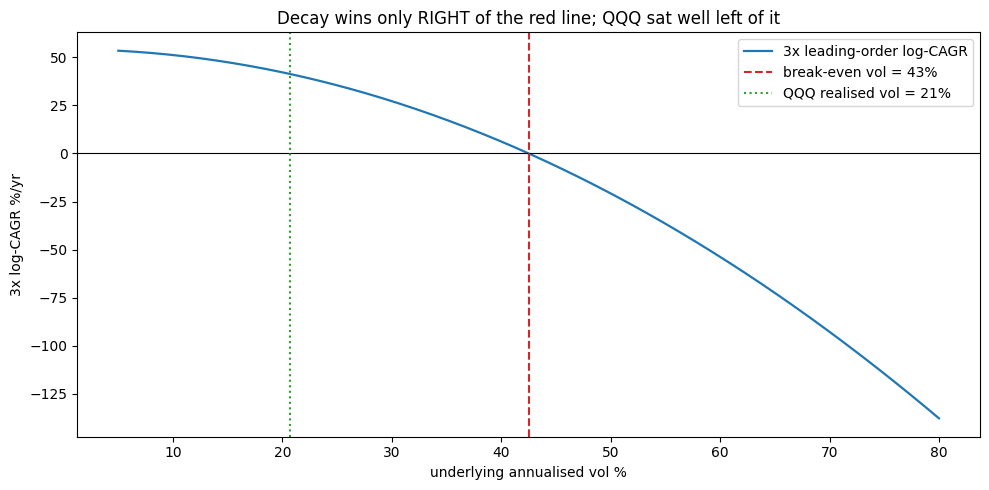

In [4]:
# Break-even curve: levered log-CAGR vs underlying vol at fixed drift (QQQ's drift).
d = strategy.drag_decomposition(uc, k=3.0); g = d['g_daily']
vols = np.linspace(0.05, 0.80, 200); s2 = (vols/np.sqrt(252))**2
lev = (3*g - 3*s2) * 252 * 100   # k(k-1)/2 = 3 for k=3
be = d['breakeven_vol_ann']*100
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(vols*100, lev, lw=1.6, label='3x leading-order log-CAGR')
ax.axhline(0, color='k', lw=.8)
ax.axvline(be, color='C3', ls='--', label=f'break-even vol = {be:.0f}%')
ax.axvline(d['realized_vol_ann']*100, color='C2', ls=':', label=f"QQQ realised vol = {d['realized_vol_ann']*100:.0f}%")
ax.set_xlabel('underlying annualised vol %'); ax.set_ylabel('3x log-CAGR %/yr'); ax.legend()
ax.set_title('Decay wins only RIGHT of the red line; QQQ sat well left of it'); plt.tight_layout(); plt.show()

> 💡 **In plain words:** decay isn't a switch that's always on — it's the right half of this curve. The 2010s NASDAQ lived on the left half, where leverage *adds* compound growth.

**Path-dependence** — same fund, three regimes (QQQ underlying):

In [5]:
qqq = data.load_real('QQQ', mode='total_return')['close'].loc[:AS_OF]
rows = []
for lo, hi, lab in [('2010-02-11','2021-12-31','2010-21 bull'),('2018-01-01','2018-12-31','2018 chop'),('2022-01-01','2022-12-31','2022 selloff')]:
    seg = qqq.loc[lo:hi]; rvn = strategy.realized_vs_naive(seg, k=3.0); d = strategy.drag_decomposition(seg, k=3.0)
    rows.append([lab, (seg.iloc[-1]/seg.iloc[0]-1)*100, (rvn['realized_final']-1)*100, (rvn['naive_final']-1)*100, d['realized_vol_ann']*100, d['drag_dominates']])
pd.DataFrame(rows, columns=['regime','QQQ %','real 3x %','naive 3x %','vol %','drag dom?']).set_index('regime').round(1)

,QQQ %,real 3x %,naive 3x %,vol %,drag dom?
regime,,,,,
2010-21 bull,922.200,"14,566.500","2,766.600",19.600,False
2018 chop,-1.800,-23.100,-5.500,22.900,True
2022 selloff,-33.200,-79.300,-99.700,32.200,True


**Drawdown** — the real cost. Simulated 3x vs underlying:

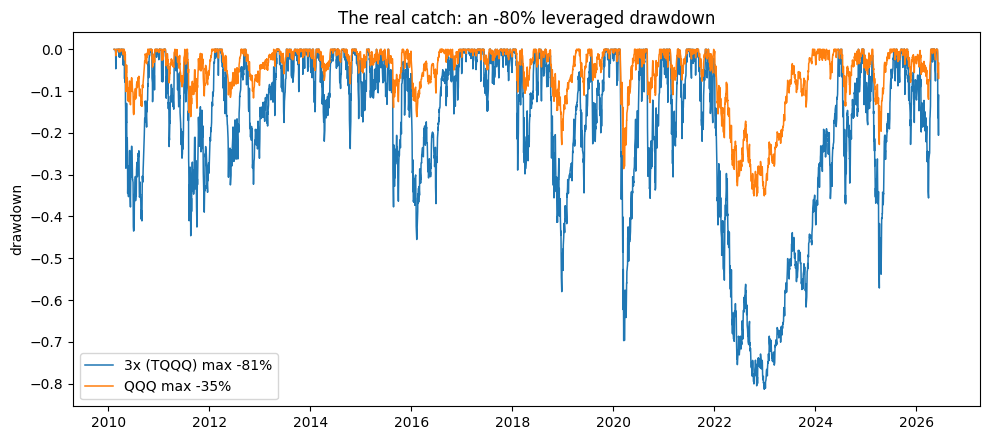

In [6]:
dd_lev = nav/nav.cummax()-1; dd_un = under_n/under_n.cummax()-1
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(dd_lev, label=f'3x (TQQQ) max {dd_lev.min()*100:.0f}%', lw=1.1)
ax.plot(dd_un, label=f'QQQ max {dd_un.min()*100:.0f}%', lw=1.1)
ax.set_ylabel('drawdown'); ax.legend(); ax.set_title('The real catch: an -80% leveraged drawdown'); plt.tight_layout(); plt.show()

> 💡 **In plain words:** the danger that's actually real isn't a slow bleed — it's the cliff. An −80% drawdown needs a +400% recovery just to get back to even.

## 5 · The verdict

Signal `REAL` on the mechanism (reproduction corr 0.9989/0.9983; drag is exact maths), **`BUSTED`** on the doom (realised 3x ended far above naive-3x in both tapes), Tradability `MIRAGE` for 'hold forever' (+24/+18 pts/yr but worse Sharpe and -81.7%/-76.8% drawdown). Decay is path-dependent; the catch is leverage risk, not a bleed law.

## 6 · Could you trade it?

Capacity is a non-issue (TQQQ/UPRO are deeply liquid). The binding facts are economic: (1) the spectacular CAGR is **regime-conditional leveraged beta** — it required the 2010s trend and would invert in a lost decade; (2) the **Sharpe is *lower* than the underlying**, so you took on more risk than you were paid for; (3) the **−80% drawdown** is the true tail. A trend-conditional overlay or a 2x sleeve is the obvious risk-managed variant.

## 7 · Going further

- Solve the break-even **per calendar year** and overlay it on realised vol — when did each fund cross into the decay half?
- Bootstrap the **Sharpe difference** (3x − underlying) with a stationary bootstrap for a CI.
- Repeat for **inverse** (SQQQ) and **2x** (QLD) — the `(k(k−1)/2)` drag is largest for inverse leverage; quantify it.